In [1]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler  
from sklearn.model_selection import train_test_split 
import torch  
import torch.nn as nn  
import torch.optim as optim 


In [ ]:

time_steps = np.linspace(0, 100, 500)  
data = np.sin(time_steps) 
df = pd.DataFrame(data, columns=['value']) 


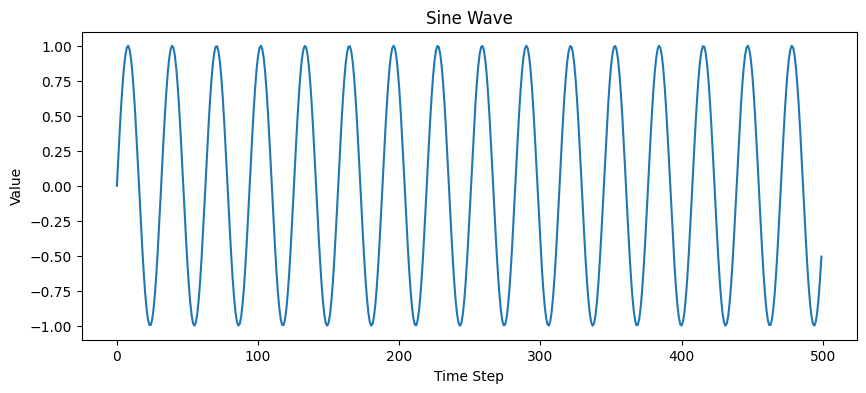

In [3]:
plt.figure(figsize=(10, 4)) 
plt.plot(df['value']) 
plt.title("Sine Wave") 
plt.xlabel("Time Step") 
plt.ylabel("Value") 
plt.show() 


In [4]:
scaler = MinMaxScaler() 

df['value'] = scaler.fit_transform(df[['value']]) 
  
data = df['value'].values  


In [ ]:
def create_sequences(data, seq_length):  
  xs, ys = [], []  
  for i in range(len(data) - seq_length):  
    x = data[i:i+seq_length]  
    y = data[i+seq_length] 
    xs.append(x)  
    ys.append(y)  
  return np.array(xs), np.array(ys)  
 
SEQ_LENGTH = 20   

X, y = create_sequences(data, SEQ_LENGTH)  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)  


X_train = torch.Tensor(X_train).unsqueeze(-1) # Shape: (batch, seq, input_size)  
y_train = torch.Tensor(y_train)  
X_test = torch.Tensor(X_test).unsqueeze(-1)  
y_test = torch.Tensor(y_test) 


In [ ]:
class BasicRNN(nn.Module):  
  def __init__(self, input_size=1, hidden_size=64, num_layers=1):  
    super(BasicRNN, self).__init__() 
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)  
    self.fc = nn.Linear(hidden_size, 1) 

  def forward(self, x): 
    out, _ = self.rnn(x)         
    out = out[:, -1, :]           
    return self.fc(out)          
  

model = BasicRNN() 


In [ ]:
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.01) 
  
EPOCHS = 100 

losses = [] 
  
for epoch in range(EPOCHS): 
  model.train() 
  output = model(X_train) 
  loss = criterion(output.squeeze(), y_train)  

  optimizer.zero_grad() 
  loss.backward() 
  optimizer.step() 
  
  losses.append(loss.item()) 
  
  if (epoch + 1) % 10 == 0: 
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}") 


Epoch [10/100], Loss: 0.0044
Epoch [20/100], Loss: 0.0307
Epoch [30/100], Loss: 0.0248
Epoch [40/100], Loss: 0.0019
Epoch [50/100], Loss: 0.0014
Epoch [60/100], Loss: 0.0004
Epoch [70/100], Loss: 0.0003
Epoch [80/100], Loss: 0.0002
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0001


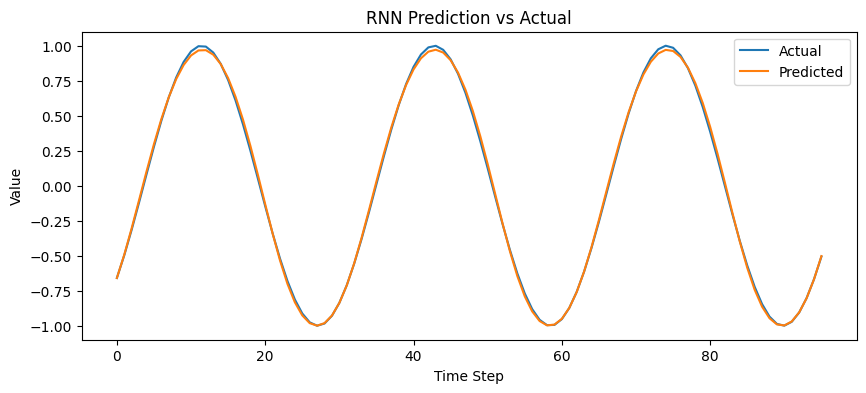

In [ ]:
model.eval()  
with torch.no_grad():  
  predictions = model(X_test).squeeze().numpy() 


y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))  
predictions_inv = scaler.inverse_transform(predictions.reshape(-1, 1))  


plt.figure(figsize=(10, 4))  
plt.plot(y_test_inv, label='Actual')  
plt.plot(predictions_inv, label='Predicted')  
plt.title("RNN Prediction vs Actual")  
plt.xlabel("Time Step")  
plt.ylabel("Value")  
plt.legend()  
plt.show() 
